<h1>Спектральные метрики сигнала</h1>

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [ ]:
y, sr = librosa.load(librosa.ex('trumpet'), duration=3.0)

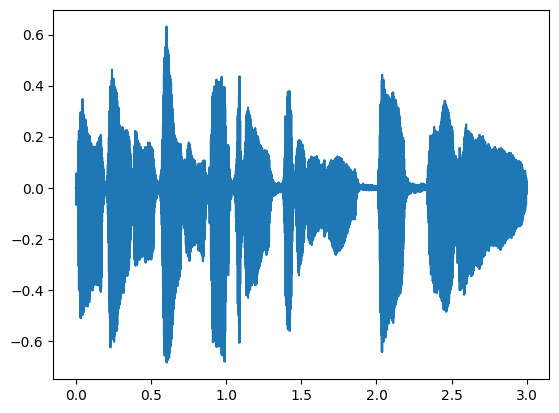

In [ ]:
plt.plot(np.linspace(0, 3, len(y)), y)

In [ ]:
from IPython.display import Audio
Audio(y, rate=sr)

<h2>H1-H2</h2>

Разница амплитуд первой и второй гармоник в децибелах:
$$H1 - H2 = 20log_{10}\frac{A_1}{A_2} = 20log_{10}A_1 - 20log_{10}A_2$$

Text(0.5, 0, 'Временные окна')

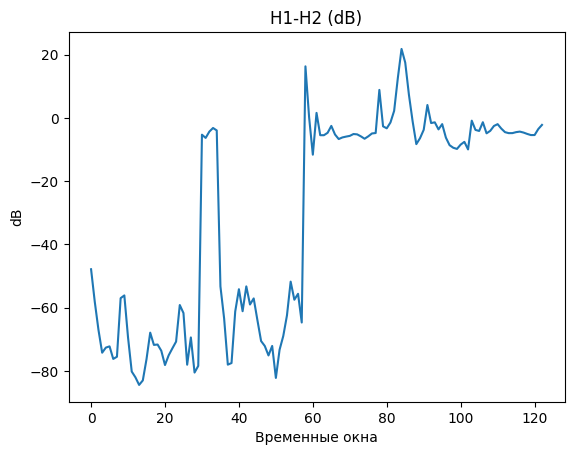

In [ ]:
# Считаем ЧОТ
f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=80, fmax=450, sr=sr)

# Находим в спектре гармоники, соответствующие ЧОТ и 2*ЧОТ
def get_harmonic_amplitudes(y, sr, f0, harmonic_n=2):
    D = librosa.stft(y)
    freqs = librosa.fft_frequencies(sr=sr)
    ampls = np.abs(D)

    h1_vals, h2_vals = [], []
    for t in range(min(len(f0), ampls.shape[1])):
        if np.isnan(f0[t]):
            continue
        f0_hz = f0[t]
        # Ищем ближайшие к ЧОТ и 2*ЧОТ частотные бины
        h1_idx = np.argmin(np.abs(freqs - f0_hz))
        h2_idx = np.argmin(np.abs(freqs - 2*f0_hz))
        h1_vals.append(ampls[h1_idx, t])
        h2_vals.append(ampls[h2_idx, t])

    h1_db = librosa.amplitude_to_db(np.array(h1_vals))
    h2_db = librosa.amplitude_to_db(np.array(h2_vals))
    return h1_db - h2_db

h1_minus_h2 = get_harmonic_amplitudes(y, sr, f0)

plt.figure()
plt.plot(h1_minus_h2)
plt.title('H1-H2 (dB)')
plt.ylabel('dB')
plt.xlabel('Временные окна')

<h2>Спектральный наклон (spectral tilt)</h2>
Наклон спектральной огибающей в log-log масштабе

$f_k, S_k$ - частота и амплитуда в k-м бине

$$x_k = ln(f_k)$$
$$y_k = ln(S_k)$$

$\bar x,  \bar y$ - средние значения чатоты и амплитуды в log-масштабе

N - число бинов

$$\beta = \frac{\sum_{k=1}^N(x_k - \bar x)(y_k - \bar y)}{\sum_{k=1}^N(x_k - \bar x)^2}$$

Text(0.5, 1.0, 'Изменение спектрального наклона во времени')

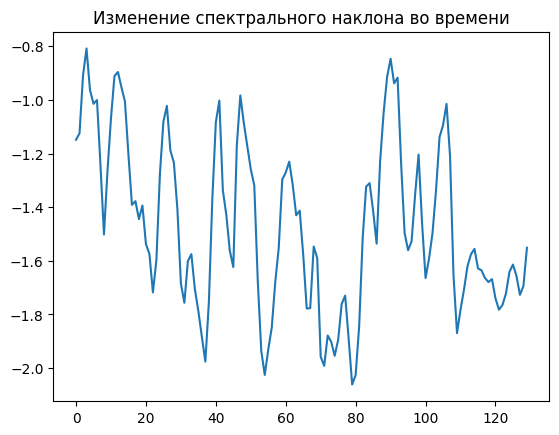

In [ ]:
def spectral_tilt(y, sr, n_fft=2048, hop_length=512):
    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    ampls = np.abs(D)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    log_freqs = np.log(freqs[1:])  # Не включаем ЧОТ
    tilt = []
    for frame in ampls.T:
        log_ampl = np.log(frame[1:] + 1e-10)
        # Линейная регрессия (полином степени 1), считается по формуле выше
        slope, _ = np.polyfit(log_freqs, log_ampl, 1)
        tilt.append(slope)
    return np.array(tilt)

tilt = spectral_tilt(y, sr)

plt.figure()
plt.plot(tilt)
plt.title('Изменение спектрального наклона во времени')

<h2>Спектральный центроид (spectral centroid) и спектральный спад (spectral rolloff)</h2>
Могут быть автоматически рассчитаны с помощью librosa.

Спектральный центроид - "центр масс" спектра, взвешенный по амплитудам составляющих:

$$Centroid = \frac{\sum_{k=1}^{N}f_k S_k}{\sum_{k=1}^{N}S_k}$$

Спектральный спад - частота $f_r$, ниже которой сосредоточен определенный процент $p$ энергии спектра:

$$\frac{\sum_{k: f_k < f_r} S_k^2}{\sum_{k=1}^N S_k^2} \geq \frac{p}{100}$$

<h2> </h2>

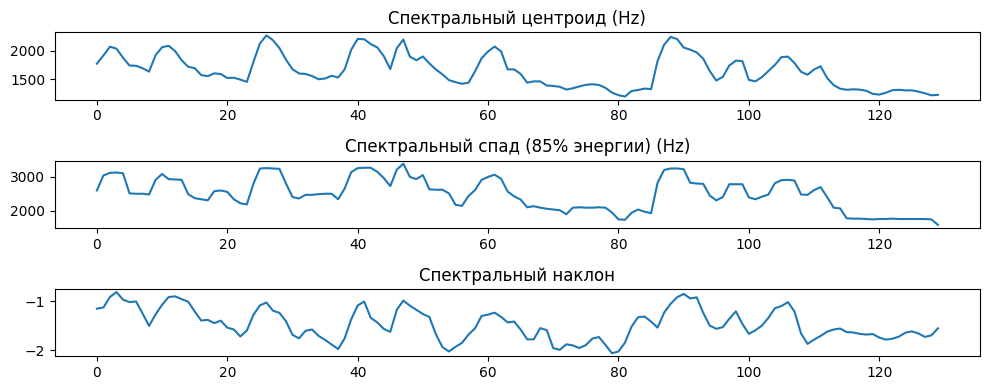

In [ ]:
# Спектральный центроид
cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]

# Спектральный спад (85% энергии)
rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)[0]

frames = range(len(cent))
plt.figure(figsize=(10, 4))
plt.subplot(3,1,1)
plt.plot(frames, cent)
plt.title('Спектральный центроид (Hz)')
plt.subplot(3,1,2)
plt.plot(frames, rolloff)
plt.title('Спектральный спад (85% энергии) (Hz)')
plt.subplot(3,1,3)
plt.plot(tilt)
plt.title('Спектральный наклон')
plt.tight_layout()

Задание. Для гармонической части сигнала с готовой разметкой на периоды ОТ для каждого периода вычислите H1-H2, спектральный наклон и спектральный центроид. Как вычислять спектр одного периода ОТ с достаточной точностью, можно посмотреть в предыдущей лекции.

In [ ]:
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/dsp/audio/cta0001.wav
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/dsp/audio/cta0001.seg